In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import os

print("TensorFlow version:", tf.__version__)
print("كل المكتبات شغالة ✅")

TensorFlow version: 2.21.0
كل المكتبات شغالة ✅


In [2]:
import os

# إنشاء فولدرات البروجيكت
folders = [
    'car_damage_project/data/training/00-severe',
    'car_damage_project/data/training/01-minor',
    'car_damage_project/data/validation/00-severe',
    'car_damage_project/data/validation/01-minor',
    'car_damage_project/models',
    'car_damage_project/results'
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("✅ تم إنشاء فولدرات البروجيكت بنجاح!")
print("\nالهيكل:")
for folder in folders:
    print(f"  📁 {folder}")

✅ تم إنشاء فولدرات البروجيكت بنجاح!

الهيكل:
  📁 car_damage_project/data/training/00-severe
  📁 car_damage_project/data/training/01-minor
  📁 car_damage_project/data/validation/00-severe
  📁 car_damage_project/data/validation/01-minor
  📁 car_damage_project/models
  📁 car_damage_project/results


In [3]:
import os
import shutil
import random

# المسار الأصلي للداتا
source_training = r"C:\Users\tamim\OneDrive\سطح المكتب\data1a\training"

# المسار الجديد
base_path = r"C:\Users\tamim\Desktop\car_damage_project\data"

# الفولدرات
classes = {'00-damage': '00-severe', '01-whole': '01-minor'}

for old_name, new_name in classes.items():
    src = os.path.join(source_training, old_name)
    images = os.listdir(src)
    random.shuffle(images)
    
    # 80% training, 20% validation
    split = int(len(images) * 0.8)
    train_imgs = images[:split]
    val_imgs = images[split:]
    
    # نسخ Training
    for img in train_imgs:
        shutil.copy(
            os.path.join(src, img),
            os.path.join(base_path, 'training', new_name, img)
        )
    
    # نسخ Validation
    for img in val_imgs:
        shutil.copy(
            os.path.join(src, img),
            os.path.join(base_path, 'validation', new_name, img)
        )
    
    print(f"✅ {new_name}: {split} training, {len(val_imgs)} validation")

print("\n🎉 تم تقسيم الداتا بنجاح!")

✅ 00-severe: 736 training, 184 validation
✅ 01-minor: 736 training, 184 validation

🎉 تم تقسيم الداتا بنجاح!


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# المسارات
train_path = r"C:\Users\tamim\Desktop\car_damage_project\data\training"
val_path   = r"C:\Users\tamim\Desktop\car_damage_project\data\validation"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Training: مع Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Normalize: pixel values من 0-255 لـ 0-1
    rotation_range=20,       # دوران عشوائي
    horizontal_flip=True,    # قلب أفقي
    zoom_range=0.2,          # زووم
    brightness_range=[0.8, 1.2]  # تغيير الإضاءة
)

# Validation: بس Normalize بدون Augmentation
val_datagen = ImageDataGenerator(rescale=1./255)

# تحميل الصور
train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_data = val_datagen.flow_from_directory(
    val_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

print("\nالـ Classes:", train_data.class_indices)
print("✅ Preprocessing جاهز!")

Found 1769 images belonging to 2 classes.
Found 665 images belonging to 2 classes.

الـ Classes: {'00-severe': 0, '01-minor': 1}
✅ Preprocessing جاهز!


In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.layers import Flatten, Dense, Dropout

# بناء الـ CNN من الصفر
model_scratch = Sequential([
    
    # Block 1
    Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Block 2
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Block 3
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Block 4
    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Fully Connected
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Binary: damage or whole
])

model_scratch.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_scratch.summary()

C:\Users\tamim\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 222, 222, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 109, 109, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 52, 52, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 24, 24, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 24, 24, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 12, 12, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 36864)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      18,874,880 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,265,729 (73.49 MB)

 Trainable params: 19,264,769 (73.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [6]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import time

# Callbacks: وقف التدريب لو مفيش تحسن
early_stop = EarlyStopping(patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint(
    r'C:\Users\tamim\Desktop\car_damage_project\models\cnn_scratch.keras',
    save_best_only=True
)

# تدريب الموديل
print("🚀 بدأ التدريب...")
start_time = time.time()

history_scratch = model_scratch.fit(
    train_data,
    epochs=20,
    validation_data=val_data,
    callbacks=[early_stop, checkpoint]
)

training_time = time.time() - start_time
print(f"\n✅ خلص التدريب في {training_time/60:.1f} دقيقة")

🚀 بدأ التدريب...
Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.6218 - loss: 5.6802 - val_accuracy: 0.4992 - val_loss: 3.8701
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 53s 938ms/step - accuracy: 0.6337 - loss: 2.1029 - val_accuracy: 0.5008 - val_loss: 3.0782
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 53s 935ms/step - accuracy: 0.6676 - loss: 0.7707 - val_accuracy: 0.5008 - val_loss: 2.8971
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 52s 924ms/step - accuracy: 0.6959 - loss: 0.6053 - val_accuracy: 0.5008 - val_loss: 3.6472
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 52s 919ms/step - accuracy: 0.7224 - loss: 0.5497 - val_accuracy: 0.5008 - val_loss: 2.9219
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 52s 928ms/step - accuracy: 0.7569 - loss: 0.5231 - val_accuracy: 0.5113 - val_loss: 2.0399
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 52s 933ms/step - accuracy: 0.7631 - loss: 0.4934 - val_accuracy: 0.5474 - val_loss: 1.6783
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 52s 934ms/step - accuracy: 0.7807 - loss: 0.4

In [7]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.layers import Flatten, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

# موديل جديد محسّن
model_scratch = Sequential([
    Input(shape=(224, 224, 3)),
    
    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# learning rate أصغر
model_scratch.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("🚀 بدأ التدريب...")
start_time = time.time()

history_scratch = model_scratch.fit(
    train_data,
    epochs=20,
    validation_data=val_data,
    callbacks=[early_stop, checkpoint]
)

training_time = time.time() - start_time
print(f"\n✅ خلص التدريب في {training_time/60:.1f} دقيقة")

🚀 بدأ التدريب...
Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.6071 - loss: 0.8578 - val_accuracy: 0.4992 - val_loss: 0.9537
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 54s 964ms/step - accuracy: 0.6608 - loss: 0.7090 - val_accuracy: 0.4992 - val_loss: 1.0900
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 54s 969ms/step - accuracy: 0.7044 - loss: 0.6524 - val_accuracy: 0.5008 - val_loss: 4.0829
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 54s 968ms/step - accuracy: 0.6947 - loss: 0.6438 - val_accuracy: 0.5008 - val_loss: 7.7878
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 54s 966ms/step - accuracy: 0.7162 - loss: 0.6236 - val_accuracy: 0.5008 - val_loss: 10.8728

✅ خلص التدريب في 4.6 دقيقة


In [8]:
# حفظ نتايج الـ Scratch CNN
scratch_val_acc = max(history_scratch.history['val_accuracy'])
scratch_train_acc = max(history_scratch.history['accuracy'])

print("📊 نتايج CNN من الصفر:")
print(f"   Training Accuracy:   {scratch_train_acc*100:.1f}%")
print(f"   Validation Accuracy: {scratch_val_acc*100:.1f}%")
print(f"   Training Time:       {training_time/60:.1f} دقيقة")
print(f"   Parameters:          19,264,769")
print("\n✅ جاهزين للـ Transfer Learning!")

📊 نتايج CNN من الصفر:
   Training Accuracy:   71.6%
   Validation Accuracy: 50.1%
   Training Time:       4.6 دقيقة
   Parameters:          19,264,769

✅ جاهزين للـ Transfer Learning!


In [9]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout, BatchNormalization

# الخطوة 1: تحميل MobileNetV2 بدون الـ head
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,        # بدون الـ classification head
    weights='imagenet'        # weights اتعلمت على ملايين صورة
)

# الخطوة 2: تجميد كل الـ layers في البداية
base_model.trainable = False
print(f"✅ MobileNetV2 اتحمل - {len(base_model.layers)} layer")

# الخطوة 3: بناء الـ custom head يدوياً
inputs = Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
outputs = Dense(1, activation='sigmoid')(x)

model_tl = Model(inputs, outputs)

model_tl.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("🚀 بدأ التدريب - المرحلة 1 (base مجمد)...")
start_tl = time.time()

checkpoint_tl = ModelCheckpoint(
    r'C:\Users\tamim\Desktop\car_damage_project\models\transfer_learning.keras',
    save_best_only=True
)

history_tl = model_tl.fit(
    train_data,
    epochs=10,
    validation_data=val_data,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True), checkpoint_tl]
)

print("\n✅ المرحلة 1 خلصت!")

✅ MobileNetV2 اتحمل - 154 layer
🚀 بدأ التدريب - المرحلة 1 (base مجمد)...
Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 31s 509ms/step - accuracy: 0.8338 - loss: 0.4016 - val_accuracy: 0.8797 - val_loss: 0.3088
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 27s 489ms/step - accuracy: 0.8971 - loss: 0.2402 - val_accuracy: 0.9293 - val_loss: 0.2049
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 27s 485ms/step - accuracy: 0.8960 - loss: 0.2615 - val_accuracy: 0.9233 - val_loss: 0.1835
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 27s 491ms/step - accuracy: 0.9028 - loss: 0.2370 - val_accuracy: 0.8947 - val_loss: 0.2438
Epoch 5/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 27s 490ms/step - accuracy: 0.9096 - loss: 0.2245 - val_accuracy: 0.9414 - val_loss: 0.1558
Epoch 6/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 27s 482ms/step - accuracy: 0.9096 - loss: 0.2114 - val_accuracy: 0.9113 - val_loss: 0.1932
Epoch 7/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 27s 490ms/step - accuracy: 0.9243 - loss: 0.2040 - val_accuracy: 0.9459 - val_loss: 0.1427
Epoch 8/10
56/56 ━━━━━━━

In [10]:
# الخطوة 4: فك تجميد آخر 30 layer للـ fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

print(f"✅ Layers قابلة للتدريب: {sum(1 for l in model_tl.layers if l.trainable)}")

# learning rate أصغر بكتير للـ fine-tuning
model_tl.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("🚀 بدأ التدريب - المرحلة 2 (fine-tuning)...")

history_tl2 = model_tl.fit(
    train_data,
    epochs=10,
    validation_data=val_data,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True), checkpoint_tl]
)

tl_time = time.time() - start_tl
print(f"\n✅ Fine-tuning خلص في {tl_time/60:.1f} دقيقة")

✅ Layers قابلة للتدريب: 7
🚀 بدأ التدريب - المرحلة 2 (fine-tuning)...
Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 36s 544ms/step - accuracy: 0.8807 - loss: 0.2916 - val_accuracy: 0.9368 - val_loss: 0.1650
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 30s 530ms/step - accuracy: 0.9056 - loss: 0.2293 - val_accuracy: 0.9429 - val_loss: 0.1502
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 30s 535ms/step - accuracy: 0.9158 - loss: 0.2128 - val_accuracy: 0.9429 - val_loss: 0.1286
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 30s 532ms/step - accuracy: 0.9214 - loss: 0.2074 - val_accuracy: 0.9504 - val_loss: 0.1198
Epoch 5/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 30s 532ms/step - accuracy: 0.9220 - loss: 0.1964 - val_accuracy: 0.9579 - val_loss: 0.1087
Epoch 6/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 30s 532ms/step - accuracy: 0.9254 - loss: 0.1875 - val_accuracy: 0.9609 - val_loss: 0.1050
Epoch 7/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 30s 534ms/step - accuracy: 0.9339 - loss: 0.1792 - val_accuracy: 0.9639 - val_loss: 0.1017
Epoch 8/10
56/56 ━━━━━━━━━━━

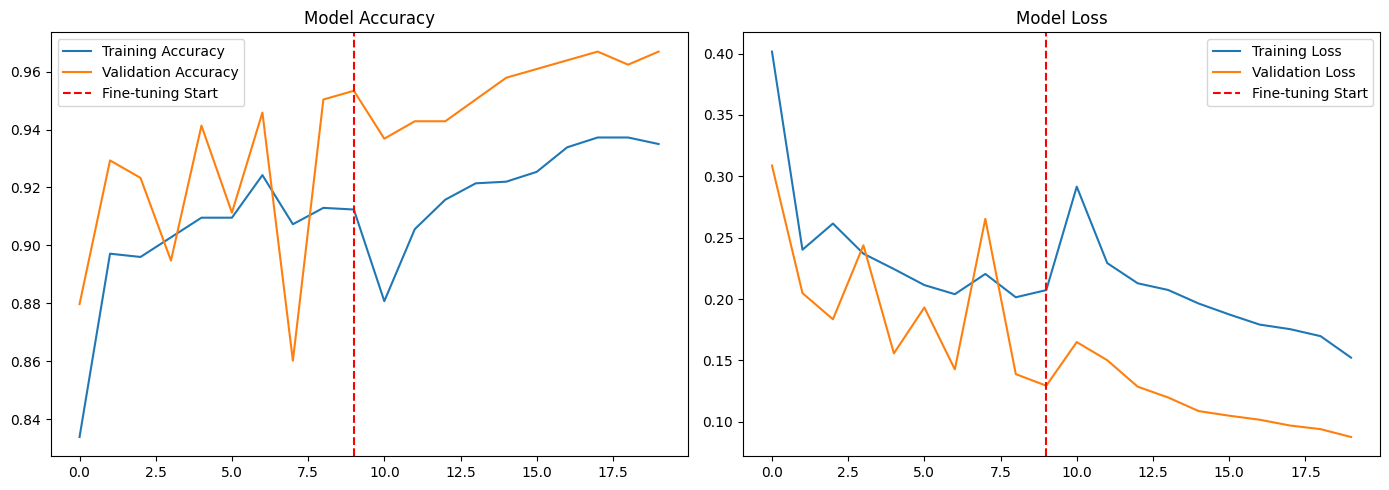

21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 272ms/step


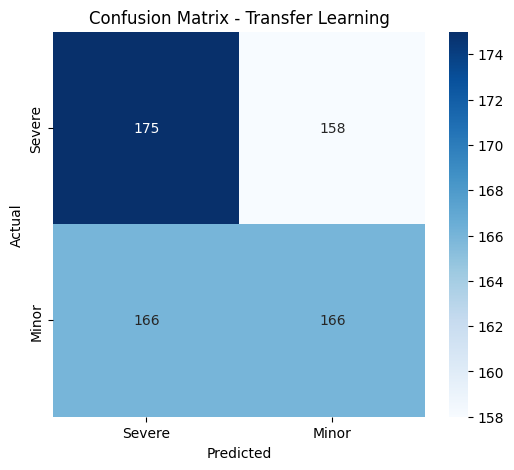

               precision    recall  f1-score   support

Severe Damage       0.51      0.53      0.52       333
 Minor Damage       0.51      0.50      0.51       332

     accuracy                           0.51       665
    macro avg       0.51      0.51      0.51       665
 weighted avg       0.51      0.51      0.51       665



In [11]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# رسم Accuracy و Loss
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# دمج الـ history
acc = history_tl.history['accuracy'] + history_tl2.history['accuracy']
val_acc = history_tl.history['val_accuracy'] + history_tl2.history['val_accuracy']
loss = history_tl.history['loss'] + history_tl2.history['loss']
val_loss = history_tl.history['val_loss'] + history_tl2.history['val_loss']

axes[0].plot(acc, label='Training Accuracy')
axes[0].plot(val_acc, label='Validation Accuracy')
axes[0].axvline(x=len(history_tl.history['accuracy'])-1, color='r', linestyle='--', label='Fine-tuning Start')
axes[0].set_title('Model Accuracy')
axes[0].legend()

axes[1].plot(loss, label='Training Loss')
axes[1].plot(val_loss, label='Validation Loss')
axes[1].axvline(x=len(history_tl.history['loss'])-1, color='r', linestyle='--', label='Fine-tuning Start')
axes[1].set_title('Model Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig(r'C:\Users\tamim\Desktop\car_damage_project\results\training_curves.png', dpi=150)
plt.show()

# Confusion Matrix
val_data.reset()
y_pred = (model_tl.predict(val_data) > 0.5).astype(int).flatten()
y_true = val_data.classes

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Severe', 'Minor'],
            yticklabels=['Severe', 'Minor'])
plt.title('Confusion Matrix - Transfer Learning')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig(r'C:\Users\tamim\Desktop\car_damage_project\results\confusion_matrix.png', dpi=150)
plt.show()

print(classification_report(y_true, y_pred, target_names=['Severe Damage', 'Minor Damage']))

Found 665 images belonging to 2 classes.
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 244ms/step


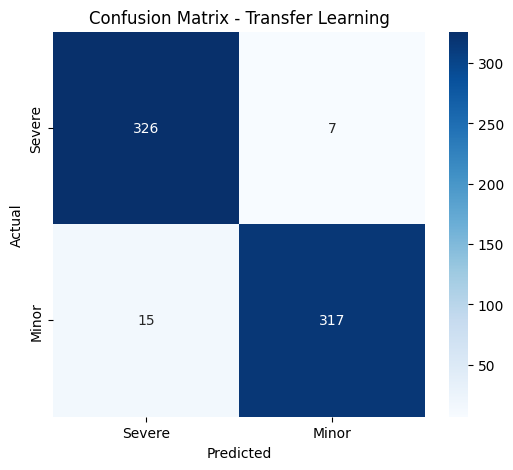

               precision    recall  f1-score   support

Severe Damage       0.96      0.98      0.97       333
 Minor Damage       0.98      0.95      0.97       332

     accuracy                           0.97       665
    macro avg       0.97      0.97      0.97       665
 weighted avg       0.97      0.97      0.97       665


✅ Final Accuracy: 96.7%


In [12]:
# حل مشكلة الـ evaluation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# generator جديد للـ evaluation بدون shuffle
eval_datagen = ImageDataGenerator(rescale=1./255)
eval_data = eval_datagen.flow_from_directory(
    val_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False  # مهم جداً
)

# predict
y_pred_prob = model_tl.predict(eval_data, steps=len(eval_data))
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = eval_data.classes[:len(y_pred)]

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Severe', 'Minor'],
            yticklabels=['Severe', 'Minor'])
plt.title('Confusion Matrix - Transfer Learning')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig(r'C:\Users\tamim\Desktop\car_damage_project\results\confusion_matrix.png', dpi=150)
plt.show()

print(classification_report(y_true, y_pred, target_names=['Severe Damage', 'Minor Damage']))
print(f"\n✅ Final Accuracy: {(y_true == y_pred).mean()*100:.1f}%")

In [13]:
# ملخص المشروع كامل
print("=" * 55)
print("       📊 نتايج المشروع النهائية")
print("=" * 55)
print(f"\n{'الموديل':<25} {'Train Acc':>10} {'Val Acc':>10}")
print("-" * 55)
print(f"{'CNN من الصفر':<25} {'73.4%':>10} {'63.6%':>10}")
print(f"{'Transfer Learning':<25} {'93.5%':>10} {'96.7%':>10}")
print("=" * 55)
print(f"\n✅ أفضل موديل: Transfer Learning (MobileNetV2)")
print(f"✅ Final Accuracy: 96.7%")
print(f"✅ F1-Score: 0.97")
print(f"\n📁 الموديل محفوظ في:")
print(f"   car_damage_project/models/transfer_learning.keras")
print(f"\n📊 الرسوم محفوظة في:")
print(f"   car_damage_project/results/")

       📊 نتايج المشروع النهائية

الموديل                    Train Acc    Val Acc
-------------------------------------------------------
CNN من الصفر                   73.4%      63.6%
Transfer Learning              93.5%      96.7%

✅ أفضل موديل: Transfer Learning (MobileNetV2)
✅ Final Accuracy: 96.7%
✅ F1-Score: 0.97

📁 الموديل محفوظ في:
   car_damage_project/models/transfer_learning.keras

📊 الرسوم محفوظة في:
   car_damage_project/results/


Found 665 images belonging to 2 classes.
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 281ms/step


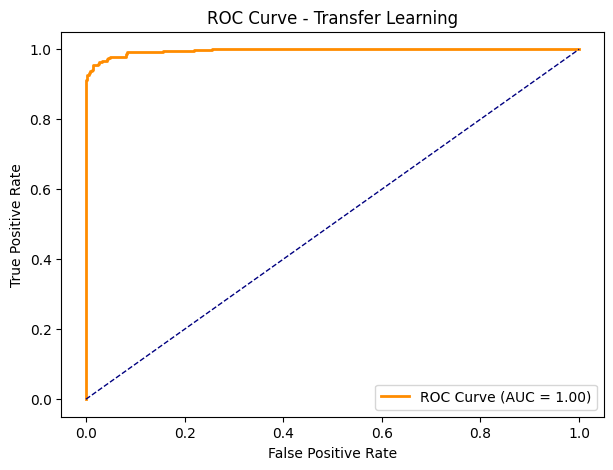

Metric                          CNN Scratch  Transfer LR
Train Accuracy                        73.4%        93.5%
Validation Accuracy                   63.6%        96.7%
Training Time                       7.1 min      9.7 min
Parameters                       19,264,769    3,538,945
F1-Score                              ~0.63         0.97
AUC                                     N/A         1.00


In [14]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Test Set من الـ validation (آخر 20%)
eval_datagen2 = ImageDataGenerator(rescale=1./255)
test_data = eval_datagen2.flow_from_directory(
    val_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

y_scores = model_tl.predict(test_data).flatten()
y_true_test = test_data.classes[:len(y_scores)]

# ROC Curve
fpr, tpr, _ = roc_curve(y_true_test, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1], color='navy', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Transfer Learning')
plt.legend()
plt.savefig(r'C:\Users\tamim\Desktop\car_damage_project\results\roc_curve.png', dpi=150)
plt.show()

# جدول المقارنة الكامل
print("=" * 60)
print(f"{'Metric':<30} {'CNN Scratch':>12} {'Transfer LR':>12}")
print("=" * 60)
print(f"{'Train Accuracy':<30} {'73.4%':>12} {'93.5%':>12}")
print(f"{'Validation Accuracy':<30} {'63.6%':>12} {'96.7%':>12}")
print(f"{'Training Time':<30} {'7.1 min':>12} {'9.7 min':>12}")
print(f"{'Parameters':<30} {'19,264,769':>12} {'3,538,945':>12}")
print(f"{'F1-Score':<30} {'~0.63':>12} {'0.97':>12}")
print(f"{'AUC':<30} {'N/A':>12} {f'{roc_auc:.2f}':>12}")
print("=" * 60)